In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr

# Period

In [6]:
iyear = 1960
fyear = 2025
seasons = ['DJFM','AM','JJAS','ON']
models = ['CHIRPS','ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']
variables = ['tcwv', 'ivt']

# TP & TCWV & IVT timeseries DOMAINS

In [7]:
tp_datasets = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for season in seasons:
    tp_datasets[season] = {}
    for model in models:
        tp_datasets[season][model] = {}
        for domain in domains:
            if model=='ERA5':
                tp_datasets[season][model][domain] = pd.read_csv(path + f'timeseries_tp_{season}_{domain}_{iyear}-{fyear}_{model}.csv')
            else:
                tp_datasets[season][model][domain] = pd.read_csv(path + f'timeseries_tp_{season}_{domain}_1981-2024_{model}.csv')

In [12]:
var_dict = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for season in seasons:
    var_dict[season] = {}
    for var in variables:
        var_dict[season][var] = {}
        for domain in domains:
            var_dict[season][var][domain] = pd.read_csv(path + f'timeseries_{var}_{season}_{domain}_{iyear}-{fyear}_ERA5.csv')

# Correlation tab

## tcwv

# ERA5

In [32]:
for var in variables:
    
    corr_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    pval_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    
    for season in seasons:
        for domain in domains:
            
            # merge pour aligner les années
            df = pd.merge(
                tp_datasets[season]['ERA5'][domain],
                var_dict[season]['tcwv'][domain],
                on='year',
                how='inner'
            )
            
            tp = df['tp'].values
            x = df['tcwv'].values
            
            # enlever NaN
            mask = (~np.isnan(tp)) & (~np.isnan(x))
            
            r, p = pearsonr(tp[mask], x[mask])
            
            corr_table.loc[domain, season] = r
            pval_table.loc[domain, season] = p

In [33]:
corr_table.round(2)

,DJFM,AM,JJAS,ON
HMA,0.68,0.47,0.44,0.37
HK,0.53,0.34,0.69,0.64
SL,0.55,0.06,0.69,0.46
TP,0.29,0.62,0.77,0.66
CH,0.61,0.81,0.57,0.50
SEH,0.43,0.57,0.06,0.38


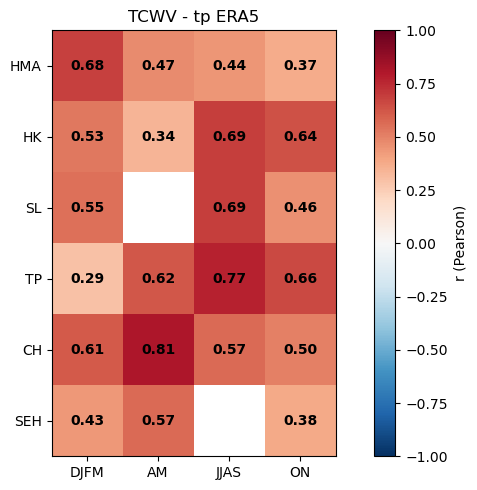

In [36]:
# récupérer tes tables
corr = corr_table.copy()
pval = pval_table.copy()

# arrondir les corrélations
corr = corr.round(2)

# masquer les valeurs non significatives
corr_masked = corr.copy()
corr_masked[pval >= 0.05] = np.nan

# plot
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('r (Pearson)')

# ticks
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)

# afficher les valeurs dans les cases
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if not np.isnan(corr_masked.iloc[i, j]):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', weight='bold')
        else:
            ax.text(j, i, "", ha='center', va='center')  # case blanche

ax.set_title('TCWV - tp ERA5')

plt.tight_layout()
plt.show()

# CHIRPS

In [37]:
for var in variables:
    
    corr_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    pval_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    
    for season in seasons:
        for domain in domains:
            
            # merge pour aligner les années
            df = pd.merge(
                tp_datasets[season]['CHIRPS'][domain],
                var_dict[season]['tcwv'][domain],
                on='year',
                how='inner'
            )
            
            tp = df['tp'].values
            x = df['tcwv'].values
            
            # enlever NaN
            mask = (~np.isnan(tp)) & (~np.isnan(x))
            
            r, p = pearsonr(tp[mask], x[mask])
            
            corr_table.loc[domain, season] = r
            pval_table.loc[domain, season] = p

In [38]:
corr_table.round(2)

,DJFM,AM,JJAS,ON
HMA,0.71,0.53,0.73,0.30
HK,0.56,0.47,0.26,0.57
SL,0.40,0.19,0.38,0.41
TP,0.06,0.24,0.67,0.49
CH,0.55,0.68,0.42,0.34
SEH,0.54,0.55,0.38,0.34


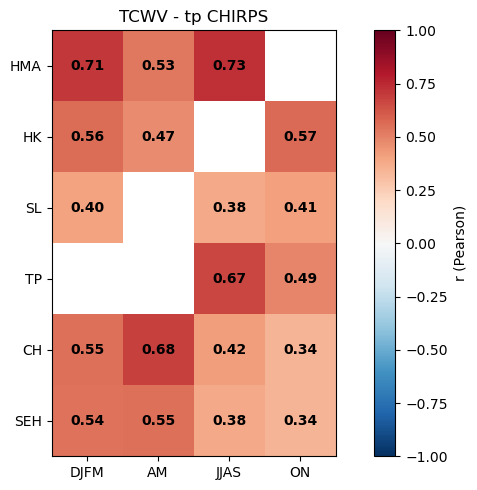

In [39]:
# récupérer tes tables
corr = corr_table.copy()
pval = pval_table.copy()

# arrondir les corrélations
corr = corr.round(2)

# masquer les valeurs non significatives
corr_masked = corr.copy()
corr_masked[pval >= 0.05] = np.nan

# plot
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('r (Pearson)')

# ticks
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)

# afficher les valeurs dans les cases
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if not np.isnan(corr_masked.iloc[i, j]):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', weight='bold')
        else:
            ax.text(j, i, "", ha='center', va='center')  # case blanche

ax.set_title('TCWV - tp CHIRPS')

plt.tight_layout()
plt.show()

## ivt

# ERA5

In [41]:
for var in variables:
    
    corr_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    pval_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    
    for season in seasons:
        for domain in domains:
            
            # merge pour aligner les années
            df = pd.merge(
                tp_datasets[season]['ERA5'][domain],
                var_dict[season]['ivt'][domain],
                on='year',
                how='inner'
            )
            
            tp = df['tp'].values
            x = df['ivt'].values
            
            # enlever NaN
            mask = (~np.isnan(tp)) & (~np.isnan(x))
            
            r, p = pearsonr(tp[mask], x[mask])
            
            corr_table.loc[domain, season] = r
            pval_table.loc[domain, season] = p

In [42]:
corr_table.round(2)

,DJFM,AM,JJAS,ON
HMA,0.80,0.45,0.37,0.27
HK,0.78,0.50,0.37,0.81
SL,0.24,-0.31,-0.22,-0.06
TP,0.08,-0.15,0.12,0.48
CH,0.31,-0.11,0.20,-0.13
SEH,0.64,0.23,0.49,0.36


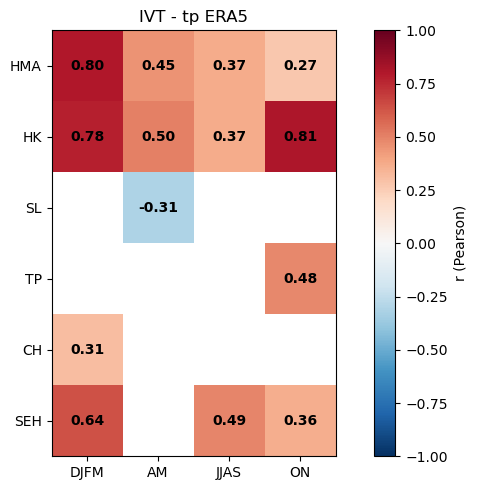

In [43]:
# récupérer tes tables
corr = corr_table.copy()
pval = pval_table.copy()

# arrondir les corrélations
corr = corr.round(2)

# masquer les valeurs non significatives
corr_masked = corr.copy()
corr_masked[pval >= 0.05] = np.nan

# plot
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('r (Pearson)')

# ticks
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)

# afficher les valeurs dans les cases
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if not np.isnan(corr_masked.iloc[i, j]):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', weight='bold')
        else:
            ax.text(j, i, "", ha='center', va='center')  # case blanche

ax.set_title('IVT - tp ERA5')

plt.tight_layout()
plt.show()

# CHIRPS

In [44]:
for var in variables:
    
    corr_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    pval_table = pd.DataFrame(index=domains, columns=seasons, dtype=float)
    
    for season in seasons:
        for domain in domains:
            
            # merge pour aligner les années
            df = pd.merge(
                tp_datasets[season]['CHIRPS'][domain],
                var_dict[season]['ivt'][domain],
                on='year',
                how='inner'
            )
            
            tp = df['tp'].values
            x = df['ivt'].values
            
            # enlever NaN
            mask = (~np.isnan(tp)) & (~np.isnan(x))
            
            r, p = pearsonr(tp[mask], x[mask])
            
            corr_table.loc[domain, season] = r
            pval_table.loc[domain, season] = p

In [45]:
corr_table.round(2)

,DJFM,AM,JJAS,ON
HMA,0.54,0.29,0.10,0.12
HK,0.59,0.46,0.29,0.72
SL,-0.07,-0.22,-0.00,-0.11
TP,0.16,0.01,-0.06,0.30
CH,0.16,-0.15,0.01,-0.22
SEH,0.51,0.12,0.29,0.20


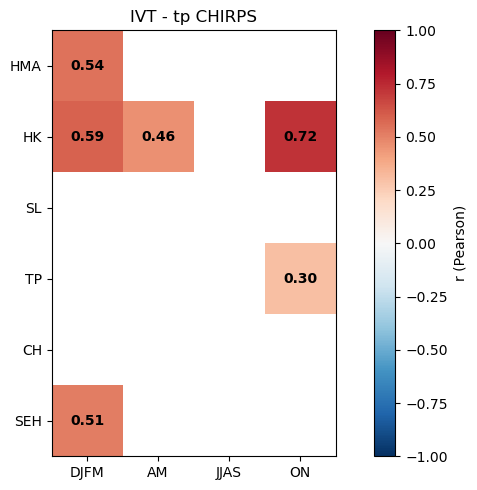

In [46]:
# récupérer tes tables
corr = corr_table.copy()
pval = pval_table.copy()

# arrondir les corrélations
corr = corr.round(2)

# masquer les valeurs non significatives
corr_masked = corr.copy()
corr_masked[pval >= 0.05] = np.nan

# plot
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('r (Pearson)')

# ticks
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)

# afficher les valeurs dans les cases
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if not np.isnan(corr_masked.iloc[i, j]):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', weight='bold')
        else:
            ax.text(j, i, "", ha='center', va='center')  # case blanche

ax.set_title('IVT - tp CHIRPS')

plt.tight_layout()
plt.show()